In [2]:
import nltk
import json
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px


from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from storage.database import Database

In [3]:
DATABASE_PATH = "../data.db"
QUANTITY = 10000
CAMPOS_ID =("id", "id_discurso")
database = Database(DATABASE_PATH)
query = "educacao publica investimento escolas professores"


try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')
nltk.download('rslp')

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\micael.conti\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

# Métodos

In [4]:
def mostrar_tabela(x,vec,title):
    df_bow = pd.DataFrame(x.toarray(), columns=vec.get_feature_names_out())
    print(title)
    display(df_bow)

In [5]:
def get_corpus(documentos, campo, campos_id=("id", "id_doc")):
    corpus = []
    doc_ids = []

    for d in documentos:
        if campo in d and d[campo]:
            corpus.append(json.loads(d[campo]))
            
            id_composto = "_".join(str(d[c]) for c in campos_id)
            doc_ids.append(id_composto)

    return corpus, doc_ids

In [6]:
def processar_dados_bow(campo, campos_id, size):
    discursos = database.get_discursos(size)
    corpus, doc_ids = get_corpus(discursos, campo, campos_id)
    
    bow_vec = CountVectorizer(
        lowercase=False,
        preprocessor=None,
        tokenizer=lambda x: x
    )
    
    X_bow = bow_vec.fit_transform(corpus)
    
    return X_bow, bow_vec, corpus, doc_ids

In [7]:
def processar_dados_td_idf(campo, campos_id, size):
    discursos = database.get_discursos(size)
    corpus , doc_ids = get_corpus(discursos, campo, campos_id)
    
    tfidf_vec = TfidfVectorizer(
        lowercase=False,
        preprocessor=None,
        tokenizer=lambda x: x
    )
    
    X_tfidf = tfidf_vec.fit_transform(corpus)
    
    return X_tfidf, tfidf_vec, corpus , doc_ids

In [8]:
def search_and_rank(query, vectorizer, X_corpus, corpus, doc_ids, method_name):
    """
    Vetoriza uma query, calcula a similaridade com o corpus e exibe os resultados.
    """
    q_vec = vectorizer.transform([query])
    sim_scores = cosine_similarity(q_vec, X_corpus).ravel()
    rank = np.argsort(sim_scores)[::-1]

    print(f"Top-3 Similares para a Query (usando {method_name}):")
    for i in rank[:3]:
        if sim_scores[i] > 0.01: # Apenas mostra se houver alguma similaridade
            print(f"  Doc{doc_ids[i]} (score={sim_scores[i]:.3f}): {corpus[i]}")
    print("-" * 40)

In [9]:
def matriz_similaridade_top_n(dados, doc_ids, top_n, subtitle = ""):
    sim_matrix = cosine_similarity(dados, dados)

    sim_no_diag = sim_matrix.copy()
    np.fill_diagonal(sim_no_diag, 0)

    mean_sim = sim_no_diag.mean(axis=1)
    top_idxs = np.argsort(mean_sim)[::-1][:top_n]

    sub_sim = sim_matrix[np.ix_(top_idxs, top_idxs)]
    
    if doc_ids is None:
        doc_ids = np.arange(len(dados))

    doc_labels = np.array(doc_ids)[top_idxs]


    df_similarity = pd.DataFrame(sub_sim, index=doc_labels, columns=doc_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_similarity, annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Heatmap dos {top_n} documentos mais semelhantes - {subtitle}")
    plt.xlabel("Documentos")
    plt.ylabel("Documentos")
    plt.tight_layout()
    plt.show()

In [10]:
def grafico2D(dados):
    pca = PCA(n_components=2)
    X_tfidf_pca = pca.fit_transform(dados.toarray())

    plt.figure(figsize=(10, 7))
    plt.scatter(X_tfidf_pca[:, 0], X_tfidf_pca[:, 1], c='blue', alpha=0.7, s=100)
    plt.title("Visualização 2D dos Vetores de Documentos")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.grid(True)

    plt.show()

In [11]:
def grafico3D(dados):
    # Redução de dimensionalidade
    pca = PCA(n_components=3)
    X_tfidf_pca = pca.fit_transform(dados.toarray())

    # Criando gráfico 3D com Plotly Express
    fig = px.scatter_3d(
        x=X_tfidf_pca[:, 0],
        y=X_tfidf_pca[:, 1],
        z=X_tfidf_pca[:, 2],
        opacity=0.7,
        title="Visualização 3D dos Vetores de Documentos"
    )

    # Ajustando labels
    fig.update_layout(
        scene=dict(
            xaxis_title="Componente Principal 1",
            yaxis_title="Componente Principal 2",
            zaxis_title="Componente Principal 3"
        )
    )

    fig.show()

# Testes

Bow (Bag-of-Words)

In [21]:
x_bow_stem, bow_vec_stem, bow_corpus_stem, doc_ids_bow_stem = processar_dados_bow("transcricao_stemizado", CAMPOS_ID, QUANTITY)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


## Transcrição

In [22]:
x_tf_idf_token,vec_tf_idf_token,corpus_tf_idf_token,doc_ids_tf_idf_token = processar_dados_td_idf("transcricao_tokens",CAMPOS_ID, QUANTITY)
x_tf_idf_stem,vec_tf_idf_stem,corpus_tf_idf_stem, doc_ids_tf_idf_stem = processar_dados_td_idf("transcricao_stemizado",CAMPOS_ID, QUANTITY)
x_tf_idf_lem,vec_tf_idf_lem,corpus_tf_idf_lem, doc_ids_tf_ids_lem = processar_dados_td_idf("transcricao_lemizado",CAMPOS_ID, QUANTITY)

In [23]:
mostrar_tabela(x_tf_idf_token,vec_tf_idf_token,"Matriz Documento-Termo Transcrição (TF-IDF)")

Matriz Documento-Termo Transcrição (TF-IDF)


,aa,aaa,aagd,aahmsnpvoqltgxmwqhxayhuogwymsawumwkealpawgyovwmehehxe,aaktzkyq,aapdp,aarao,abacateiro,abacaxi,abacc,...,zuliani,zumbi,zumbilandia,zunzunzum,zur,zurab,zwgxf,zxkj,zyon,zyrhfqo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
print(f">> Executando busca para a query: '{query}'\n")

search_and_rank(query, bow_vec_stem, x_bow_stem, bow_corpus_stem, doc_ids_bow_stem, "BoW")

search_and_rank(query, vec_tf_idf_token, x_tf_idf_token, corpus_tf_idf_token, doc_ids_tf_idf_token, "TF-IDF - token")
search_and_rank(query, vec_tf_idf_stem, x_tf_idf_stem, corpus_tf_idf_stem, doc_ids_tf_idf_stem, "TF-IDF - stem")
search_and_rank(query, vec_tf_idf_lem, x_tf_idf_lem, corpus_tf_idf_lem, doc_ids_tf_ids_lem, "TF-IDF - lem")

>> Executando busca para a query: 'educacao publica investimento escolas professores'

Top-3 Similares para a Query (usando BoW):
  Doc178866_0 (score=0.303): ['discurs', 'integr', 'encaminh', 'sra', 'deput', 'luiziann', 'lim', 'registr', 'taquigraf', 'pktcontenttypesxml', 'ej', 'uzqjzecjzhfkpxagrk', 'albdjgc', 'u', 'doagecjseerjbypbbriefosvqsfiyvaavnex', 'hvquopw', 'szcgxtl', 'ulbjjg', 'bsenuavaojovvgpnnzjsfgnmc', 'apd', 'cjellspxsf', 'sbxztfcrtsulmgkbpihiwoyeooxnwsbwdfplnqsgwgwnnxrgryvepg', 'kfqcmtncwowksbysaqwy', 'vnqnu', 'yziucnrtnbzehqlofbqqqcfxtseep', 'zlhbmbk', 'mflfwyatiwgglsmfdqym', 'wc', 'xvdfvyyvy', 'xkxzaudlqruvscpytjuundutssay', 'dgqmagfqdgrd', 'kghnf', 'hebxt', 'xeyihobvlan', 'iwyandhv', 'ahdjyx', 's', 'ykduccphbc', 'mvyicøcdoefhczz', 'irdmfgedcya', 'ckglp', 'dovbcfkpvgajftv', 'pnkgdmunahpifhcelfvynn', 'm', 'c', 'znfdpegmqp', 'vkigytlisv', 'tfiwmigpp', 'dlvxb', 'qjexmcz', 'b', 'atfsnt', 'iyairkd', 'yiz', 'jtt', 'fq', 'g', 'zex', 'csx', 'thqsffh', 'yt', 'xkfrskktkbpu', 'vm

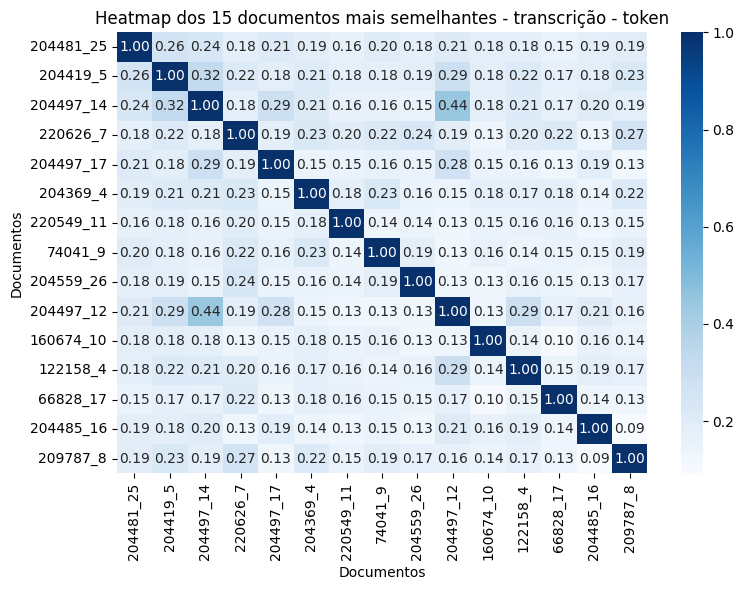

In [21]:
matriz_similaridade_top_n(x_tf_idf_token, doc_ids_tf_idf_token,15, "transcrição - token")

In [22]:
discurso_a = database.get_discurso_by_id(204497,12)
discurso_b = database.get_discurso_by_id(204497, 14)

print(discurso_a["transcricao"])
print('-'*50)
print(discurso_b["transcricao"])

O SR. JÚNIOR FERRARI (PSD - PA. Como Líder. Sem revisão do orador.) - Sr. Presidente, Sras. e Srs. Deputados, eu quero agradecer ao nosso Líder, Deputado André de Paula, a oportunidade do espaço para falar em nome da Liderança do PSD.
Quero parabenizar o Presidente da Câmara, Deputado Rodrigo Maia, pela articulação e empenho na aprovação desta reforma tão importante. Parabenizo toda a equipe da Presidência, os Deputados que votaram no primeiro turno e estão votando no segundo turno essa reforma tão importante para o nosso País.
A reforma da Previdência representa, nos próximos 10 anos, uma economia em torno de 933 bilhões de reais, ou seja, investimentos que vão ser aplicados na saúde, na educação, na segurança pública, em infraestrutura, estradas, rodovias, e outras áreas importantes para o Brasil, para que possamos melhorar a qualidade de vida do povo brasileiro.
Muito mais além, esta reforma da Previdência, além dos 933 bilhões de reais de economia, vai também gerar um efeito positi

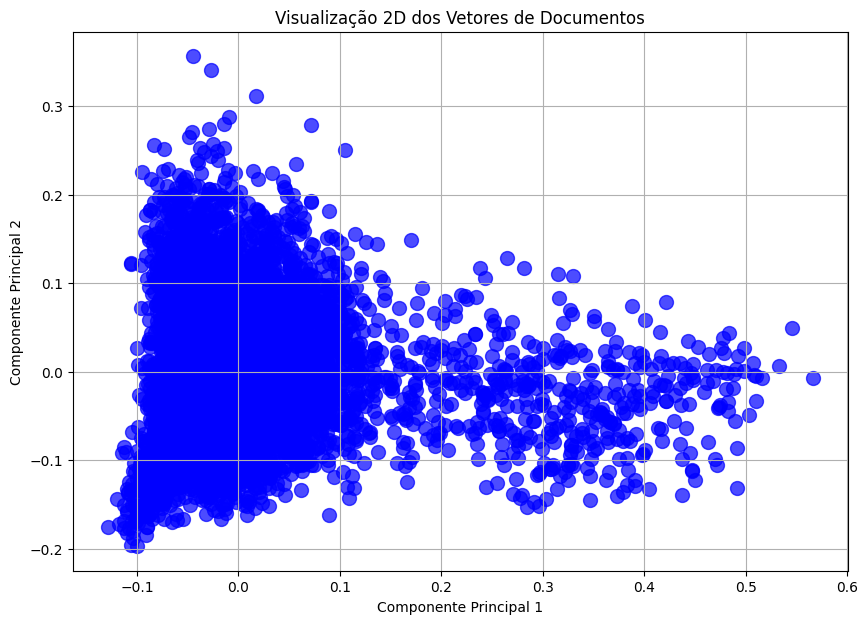

In [23]:
grafico2D(x_tf_idf_token)

In [ ]:
grafico3D(x_tf_idf_token)

## Sumário

### Tokens

In [19]:
x_sumario_tf_idf_token, vec_sumario_td_idf_token, corpus_sumario_td_idf_token, doc_ids_sumario_tf_idf_token = processar_dados_td_idf("sumario_tokens",CAMPOS_ID, QUANTITY)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [20]:
mostrar_tabela(x_sumario_tf_idf_token,vec_sumario_td_idf_token,"Matriz Documento-Termo Sumario (TF-IDF)")

Matriz Documento-Termo Sumario (TF-IDF)


,aapdp,aarao,abacateiro,abadeus,abadiania,abads,abafa,abaira,abaixo,abaixoassinados,...,zonas,zoofilia,zoologico,zoonoses,zpe,zpes,zucato,zucco,zuliani,zumbi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9661,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
search_and_rank(query, vec_sumario_td_idf_token, x_sumario_tf_idf_token, corpus_sumario_td_idf_token, doc_ids_sumario_tf_idf_token, "TF-IDF - sumario - tokens")

Top-3 Similares para a Query (usando TF-IDF - sumario - tokens):
  Doc204419_9 (score=0.306): ['realizacao', 'comissao', 'desenvolvimento', 'economico', 'industria', 'comercio', 'servicos', 'audiencia', 'publica', 'destinada', 'debate', 'relevancia', 's', 'pais']
  Doc178993_2 (score=0.256): ['deputado', 'registrou', 'preocupacao', 'decisao', 'governo', 'interino', 'tocantins', 'demitir', 'jovens', 'contratados', 'programa', 'jovem', 'trabalhador', 'afirmou', 'vagas', 'representavam', 'oportunidades', 'formais', 'emprego', 'criticou', 'transferencia', 'atividades', 's', 'nao', 'oferecia', 'contratacao', 'carteira', 'assinada', 'defendeu', 's', 'deveria', 'investir', 'qualificacao', 'profissional', 'estados', 'nao', 'substituir', 'postos', 'trabalho', 'existentes', 'classificou', 'demissoes', 'prejuizo', 'juventude']
  Doc171623_3 (score=0.250): ['defesa', 'melhoria', 'continuada', 'capacitacao', 'profissional', 'trabalhador', 'brasileiro', 'proporcionada', 'entidades', 'integrantes', '

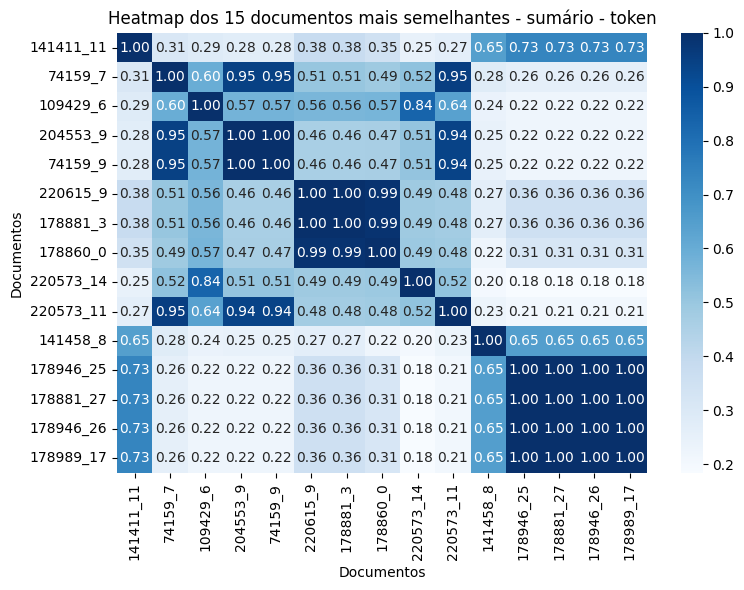

In [15]:
matriz_similaridade_top_n(x_sumario_tf_idf_token, doc_ids_sumario_tf_idf_token,15,"sumário - token")

In [ ]:
discurso_a = database.get_discurso_by_id(204553, 9)
discurso_b = database.get_discurso_by_id(109429, 6)

print(discurso_a["sumario"])
print('-'*50)
print(discurso_b["sumario"])

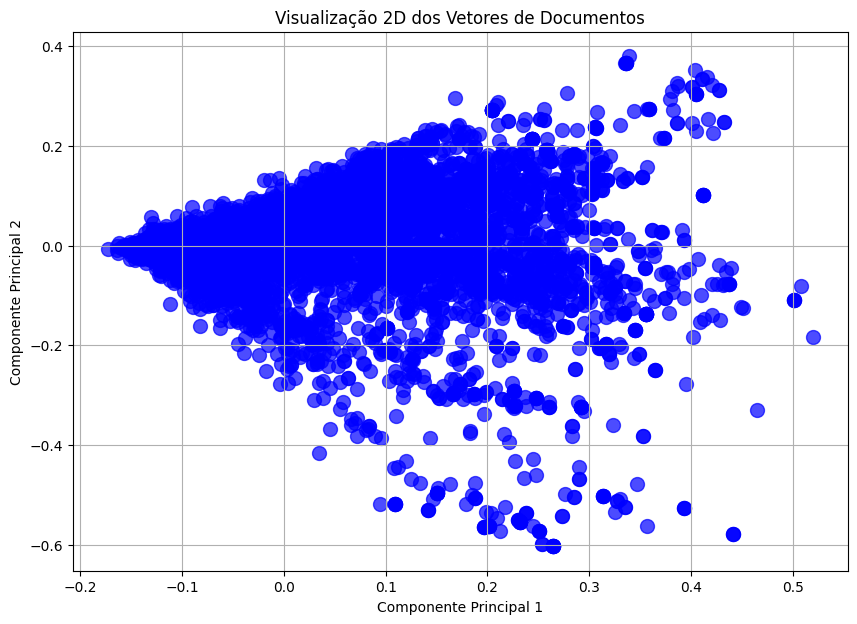

In [16]:
grafico2D(x_sumario_tf_idf_token)

In [ ]:
grafico3D(x_sumario_tf_idf_token)

### Lematização

In [17]:
x_sumario_tf_idf_lem, vec_sumario_td_idf_lem, corpus_sumario_td_idf_lem, doc_ids_sumario_tf_idf_lem = processar_dados_td_idf("sumario_lemizado",CAMPOS_ID, QUANTITY)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


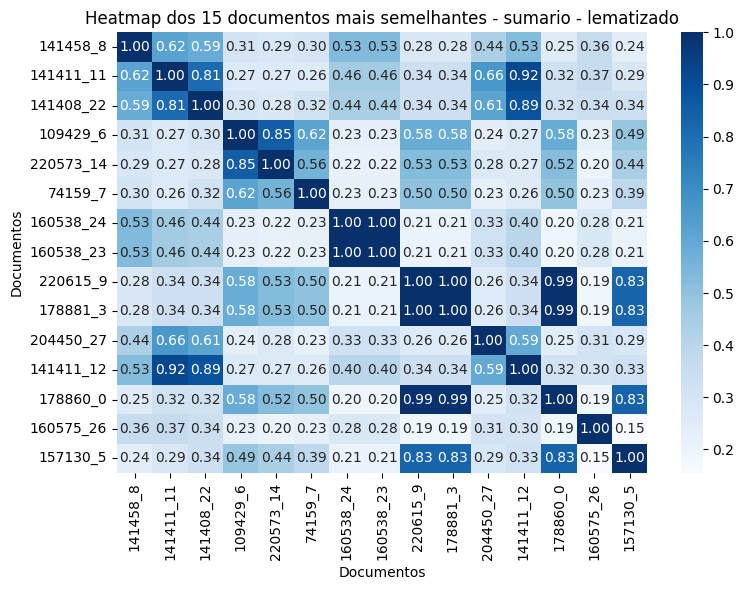

Matriz Documento-Termo Sumario (TF-IDF)


,Abandono,Abgd,Abmes,Abner,Aborto,Abrange,Abrao,Abu,Ac,Acai,...,zoofilia,zoologico,zoonoses,zpe,zpes,zucato,zucco,zulianir,zumbi,zumbir
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9661,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
matriz_similaridade_top_n(x_sumario_tf_idf_lem, doc_ids_sumario_tf_idf_lem,15, "sumario - lematizado")
mostrar_tabela(x_sumario_tf_idf_lem,vec_sumario_td_idf_lem,"Matriz Documento-Termo Sumario (TF-IDF)")

In [ ]:
search_and_rank(query, vec_sumario_td_idf_lem, x_sumario_tf_idf_lem, corpus_sumario_td_idf_lem, doc_ids_sumario_tf_idf_lem, "TF-IDF - sumario - lem")

In [ ]:
discurso_a = database.get_discurso_by_id(220573, 11)
discurso_b = database.get_discurso_by_id(74159, 9)

print(discurso_a["sumario"])
print('-'*50)
print(discurso_b["sumario"])